# Exercício Prático 3: Análise de Engajamento em Plataforma de Streaming
### Guilherme Daflon - Exercício 1.5

In [1]:
import pandas as pd

In [8]:
df = pd.read_csv('/content/streamdata_usuarios.csv')
display(df.head())

,id_usuario,plano,horas_assistidas,dispositivo_principal,score_satisfacao,cancelou_assinatura
0,USR-0001,Básico,17.5,Smart TV,5,Não
1,USR-0002,Padrão,21.3,Smartphone,4,Não
2,USR-0003,Premium,23.9,Tablet,4,Não
3,USR-0004,Básico,53.2,Smart TV,7,Não
4,USR-0005,Padrão,61.7,Tablet,5,Sim


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_usuario             250 non-null    object 
 1   plano                  250 non-null    object 
 2   horas_assistidas       250 non-null    float64
 3   dispositivo_principal  250 non-null    object 
 4   score_satisfacao       250 non-null    int64  
 5   cancelou_assinatura    250 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 11.8+ KB


In [4]:
import matplotlib.pyplot as plt

### Etapa 2: Média de Horas Assistidas por Plano (Gráfico de Barras Horizontal)
A equipe de produto precisa identificar qual plano consome mais horas de conteúdo por mês.

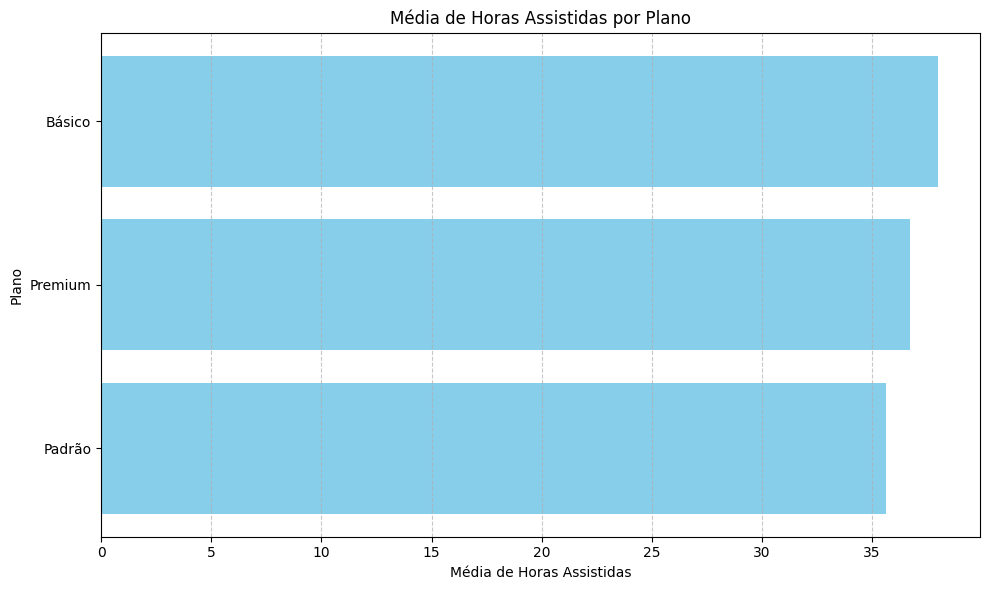

In [5]:
# Agrupe o DataFrame por plano e calcule a média de horas_assistidas.
media_horas_por_plano = df.groupby('plano')['horas_assistidas'].mean().sort_values(ascending=True)

# Crie um gráfico de barras horizontal (plt.barh).
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(media_horas_por_plano.index, media_horas_por_plano.values, color='skyblue')

# Adicione rótulos nos eixos, título explicativo e uma grade auxiliar no eixo X.
ax.set_xlabel('Média de Horas Assistidas')
ax.set_ylabel('Plano')
ax.set_title('Média de Horas Assistidas por Plano')
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Etapa 3: Relação entre Satisfação e Cancelamento (Gráfico de Dispersão / Histograma Comparativo)
Queremos saber se usuários com menores notas de satisfação cancelam mais a assinatura.

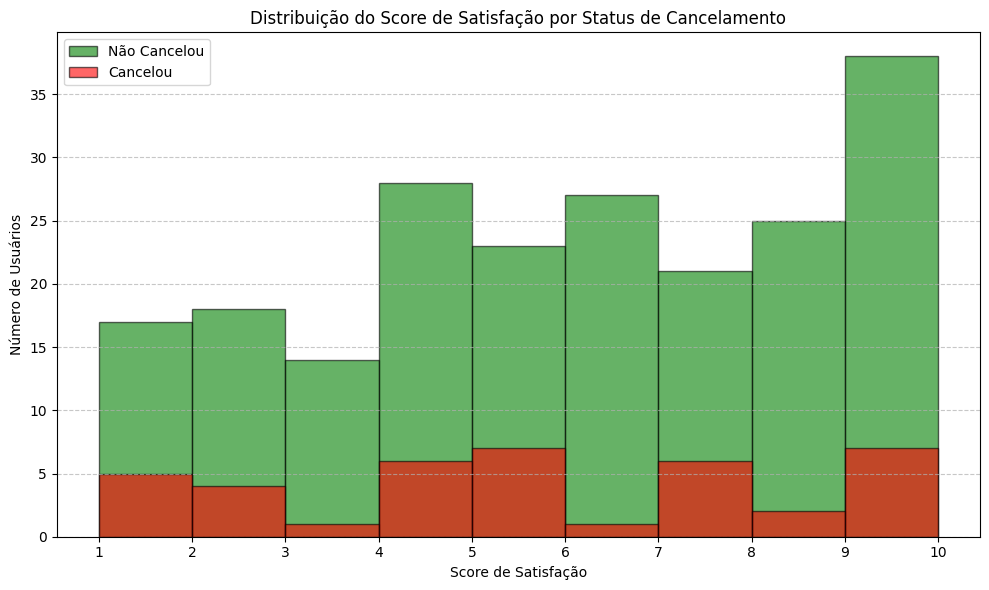

In [6]:
# Filtre os usuários em dois grupos: os que cancelaram ('Sim') e os que continuam ativos ('Não').
clientes_cancelaram = df[df['cancelou_assinatura'] == 'Sim']
clientes_ativos = df[df['cancelou_assinatura'] == 'Não']

# Crie um gráfico com dois histogramas sobrepostos (plt.hist).
plt.figure(figsize=(10, 6))
plt.hist(clientes_ativos['score_satisfacao'], bins=range(1, 11), alpha=0.6, label='Não Cancelou', color='green', edgecolor='black')
plt.hist(clientes_cancelaram['score_satisfacao'], bins=range(1, 11), alpha=0.6, label='Cancelou', color='red', edgecolor='black')

# Adicione rótulos, título e legenda.
plt.xlabel('Score de Satisfação')
plt.ylabel('Número de Usuários')
plt.title('Distribuição do Score de Satisfação por Status de Cancelamento')
plt.xticks(range(1, 11)) # Ensure x-axis ticks are for each score
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Etapa 4: Distribuição dos Dispositivos Principais (Gráfico de Pizza/Rosca)
Identifique quais dispositivos são mais utilizados pelos assinantes para priorizar o desenvolvimento de novas funcionalidades no aplicativo.

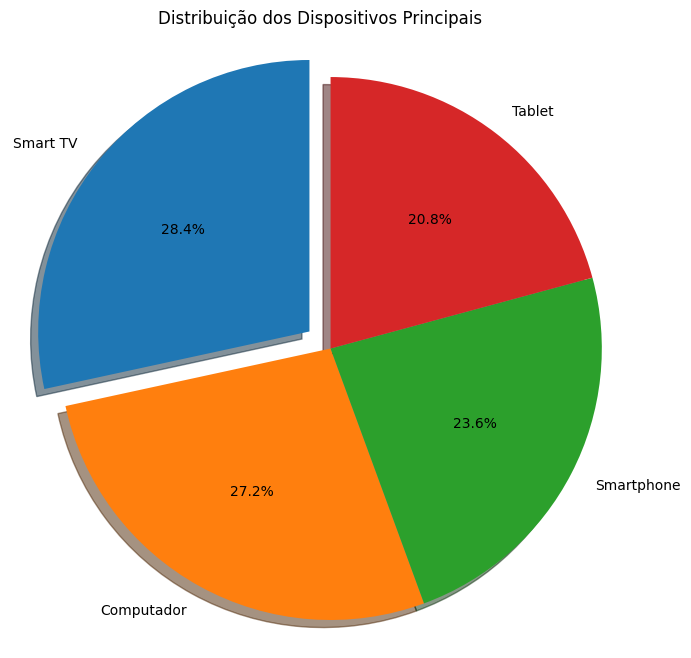

In [7]:
# Conte o total de usuários por dispositivo_principal.
contagem_dispositivos = df['dispositivo_principal'].value_counts()

# Encontre o dispositivo mais utilizado para 'explodir' no gráfico de pizza.
mais_utilizado_idx = contagem_dispositivos.idxmax()
explode = [0.1 if device == mais_utilizado_idx else 0 for device in contagem_dispositivos.index]

# Gere um gráfico de pizza.
plt.figure(figsize=(8, 8))
plt.pie(contagem_dispositivos, labels=contagem_dispositivos.index, autopct='%1.1f%%', startangle=90, explode=explode, shadow=True)
plt.title('Distribuição dos Dispositivos Principais')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo.
plt.show()